# Parallel execution of parameter scan

## 1D Run

In [1]:
import xarray as xr

import numpy as np

import time as tm

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=(RuntimeWarning, FutureWarning))

In [3]:
from func_parallel import run_model_test

No event detected


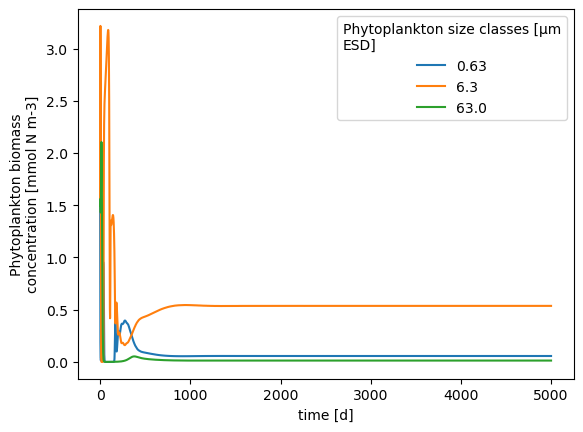

In [4]:
outttttt = run_model_test({'N0__value': 0.01005, 'HigherOrderMortality__rate': 0.01})#.Phytoplankton__biomass.plot.line(x='time')
outttttt.Phytoplankton__biomass.plot.line(x='time')

In [5]:
from multiprocessing import Pool

In [6]:
def generate_iterable_parscan(parameter, par_range):
    return [{parameter:val} for val in par_range]

In [7]:
iter_scan = generate_iterable_parscan('N0__value', np.linspace(0.001,0.2, 5))

Event triggered at t = [308.61198831]


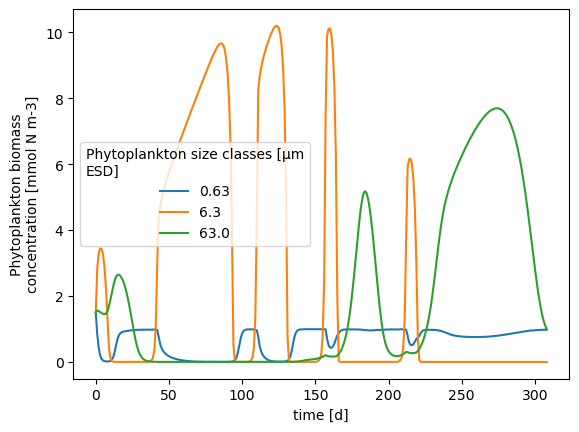

In [8]:
run_model_test(iter_scan[2]).Phytoplankton__biomass.plot.line(x='time')

In [9]:
import time as tm
p = Pool(processes=20)
start = tm.time()
data = p.map(run_model_test, iter_scan)
end = tm.time()
p.close()
print(round(end-start,5),"seconds")

3.16243 seconds
Event triggered at t = [109.01678699]
Event triggered at t = [201.65838713]
Event triggered at t = [117.62376772]
No event detected
No event detected


In [10]:
def unpack_par_scan(iterable):
    var = list(iterable[0].keys())[0]
    i_tot=len(iterable)
    
    dat_out = []
    for dat,i, val in zip(data,range(i_tot),iterable) :
        dat_out.append(dat.assign_coords({var:list(val.values())[0]}).expand_dims(var))

    data_combined = xr.combine_by_coords(dat_out)
    
    return data_combined

In [11]:
outtt = unpack_par_scan(iter_scan)

outtt

<xarray.Dataset> Size: 13MB
Dimensions:                                         (N0__value: 5, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/56)
    Core__solver_type                               (N0__value) <U9 180B 'sol...
    GGE__R                                          (N0__value) float64 40B 0...
    GGE__alpha                                      (N0__value) float64 40B 0...
    GGE__assimilated_consumer                       (N0__value) <U1 20B 'Z' ....
    GGE__assimilation_value                         (N0__value, zoo, time) float64 800kB ...
    GGE__egested_detritus                           (N0__value) <U1 20B 'N' ....
    ...                                              ...
    Phytoplankton__phyto_index                      (N0__value, phyto) float64 120B ...
    Time__time_input                                (N0__value, time) int64 200kB ...
    Zooplankton__biomass                            (N0__value, zoo, time) float64 800kB ...
    Zooplankton__biomass_init                       (N0__value, zoo) float64 160B ...
    Zooplankton__biomass_label                      (N0__value) <U1 20B 'Z' ....
    Zooplankton__zoo_index                          (N0__value, zoo) float64 160B ...

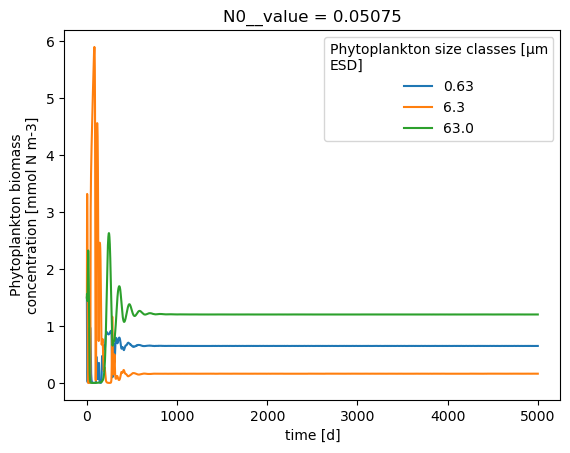

In [12]:
outtt.isel(N0__value=1).Phytoplankton__biomass.plot.line(x='time')

# 2D Par scan

In [13]:
def generate_iterable_2d_parscan(par1, par_range1, par2, par_range2):
    return [(par1,(val1, par2, generate_iterable_parscan(par2, par_range2))) for val1 in par_range1]

In [14]:
iter_scan_2d = generate_iterable_2d_parscan('N0__value', np.linspace(0.001,0.01, 5),
                             'HigherOrderMortality__rate', np.linspace(0.001,0.01, 5))

In [15]:
import time as tm
p = Pool(processes=20)
start = tm.time()
data2d = []
for iter_par1, (iter_val1, iter_par2, iter_vals2) in iter_scan_2d:
    data2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))

end = tm.time()
p.close()
print(round(end-start,5),"seconds")

6.00899 seconds
Event triggered at t = [66.76971662]
Event triggered at t = [66.7962283]
Event triggered at t = [74.80938561]
Event triggered at t = [75.84956661]
Event triggered at t = [66.20224439]
Event triggered at t = [66.76971656]
Event triggered at t = [66.7962283]
Event triggered at t = [66.20224431]
Event triggered at t = [75.84956588]
Event triggered at t = [66.76971656]
Event triggered at t = [66.7962283]
Event triggered at t = [75.84956588]
Event triggered at t = [74.80938561]


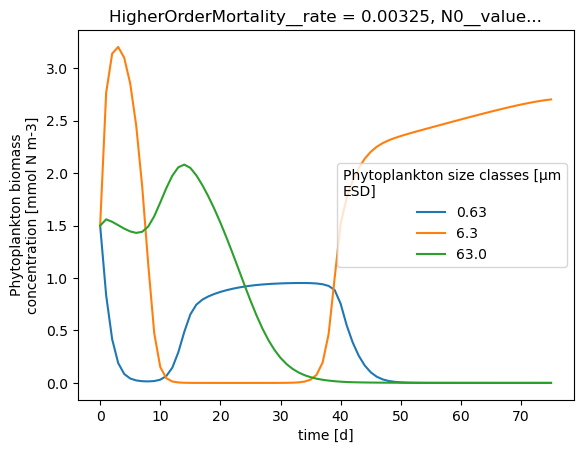

In [21]:
test_dat_out = unpack_2d_par_scan(data2d)

test_dat_out.isel(HigherOrderMortality__rate=1,N0__value=4).Phytoplankton__biomass.plot.line(x='time')

#test_dat_out.isel(HigherOrderMortality__rate=4,N0__value=2).Phytoplankton__biomass.plot.line(x='time')

In [19]:
dats_out = []
for var, (val, var2, dat) in data2d:

    dat_out = []
    for out in dat:
        #print(out)
        dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))

    data_combined = xr.combine_by_coords(dat_out)
        
    dats_out.append(data_combined)

xr.combine_by_coords(dats_out)

<xarray.Dataset> Size: 63MB
Dimensions:                                         (
                                                     HigherOrderMortality__rate: 5,
                                                     N0__value: 5, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               (HigherOrderMortality__rate, N0__value) <U9 900B ...
    GGE__R                                          (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__alpha                                      (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__assimilated_consumer                       (HigherOrderMortality__rate, N0__value) <U1 100B ...
    GGE__assimilation_value                         (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    GGE__egested_detritus                           (HigherOrderMortality__rate, N0__value) <U1 100B ...
    ...                                              ...
    Phytoplankton__phyto_index                      (HigherOrderMortality__rate, N0__value, phyto) float64 600B ...
    Time__time_input                                (HigherOrderMortality__rate, N0__value, time) int64 1MB ...
    Zooplankton__biomass                            (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    Zooplankton__biomass_init                       (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...
    Zooplankton__biomass_label                      (HigherOrderMortality__rate, N0__value) <U1 100B ...
    Zooplankton__zoo_index                          (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...

# UNPACK DATA

In [14]:
def unpack_2d_par_scan(datasets):
    dats_out = []
    for var, (val, var2, dat) in datasets:
    
        dat_out = []
        for out in dat:
            #print(out)
            dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
    
        data_combined = xr.combine_by_coords(dat_out)
            
        dats_out.append(data_combined)
    
    data_combined_2d = xr.combine_by_coords(dats_out)

    return data_combined_2d

In [23]:
mort_n0_scan = unpack_2d_par_scan(data2d)

# Start scanning and plotting results!

In [15]:
def generate_iterable_2d_parscan(par1, par_range1, par2, par_range2):
    return [(par1,(val1, par2, [{par1:val1, par2:val2} for val2 in par_range2])) for val1 in par_range1]

In [16]:
n0_mort_scan_input = generate_iterable_2d_parscan('N0__value', np.linspace(0.001,0.2, 5),
                             'HigherOrderMortality__rate', np.linspace(0.0001,0.05, 15))

In [59]:
#n0_mort_scan_input = generate_iterable_2d_parscan_fix('N0__value', np.linspace(0.001,0.2, 5),
#                             'HigherOrderMortality__rate', np.linspace(0.0001,0.05, 5))


[0.001   0.00125 0.0015  0.00175 0.002  ]


In [17]:
def unpack_2d_par_scan(datasets):
    dats_out = []
    for var, (val, var2, dat) in datasets:
        #print(var, val, var2)
        dat_out = []
        for out in dat:
            #print(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
            dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
    
        data_combined = xr.combine_by_coords(dat_out)
            
        dats_out.append(data_combined)
    
    data_combined_2d = xr.combine_by_coords(dats_out)

    return data_combined_2d

In [32]:
def run_model_get_output(iterable_in):

    p = Pool(processes=20)
    print("pool started")
    start = tm.time()
    data_2d = []
    for iter_par1, (iter_val1, iter_par2, iter_vals2) in iterable_in:
        print("running", iter_par1, iter_val1, iter_par2)#, iter_vals2)
        data_2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))
    
    end = tm.time()
    p.close()
    print("Full scan done in ",round(end-start,5),"seconds")

    scan_output = unpack_2d_par_scan(data_2d)
    return scan_output

In [151]:
n0_mort_scan_input = generate_iterable_2d_parscan('N0__value', np.linspace(0.001,0.2, 4),
                             'HigherOrderMortality__rate', np.linspace(0.0001,0.05, 100))

mort_n0_scan = run_model_get_output(n0_mort_scan_input)

pool started
running N0__value 0.001 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running N0__value 0.06733333333333334 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running N0__value 0.13366666666666668 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running N0__value 0.2 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


Full scan done in  2079.96568 seconds
N0__value 0.001 HigherOrderMortality__rate
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [141.75735137]
Event triggered at t = [164.77055481]
Event triggered at t = [178.59875693]
No event detected
No event detected
Event triggered at t = [35.34714541]
Event triggered at t = [37.34444709]
Event triggered at t = [36.29489904]
Event triggered at t = [36.94513784]
Event triggered at t = [36.29216306]
Event triggered at t = [36.81082311]
Event triggered at t = [36.33202585]
Event triggered at t = [36.26694048]
Event triggered at t = [34.40572029]
Event triggered at t = [34.75378044]
No event detected
No event detected
Event triggered at t = [30.48508644]
Event triggered at t = [30.48938653]
Event triggered at t = [233.76531316]
Event triggered at t = [243.44649942]
Event triggered at t = [125.96320382]
Event triggered at t = [126.54744481]
No event de

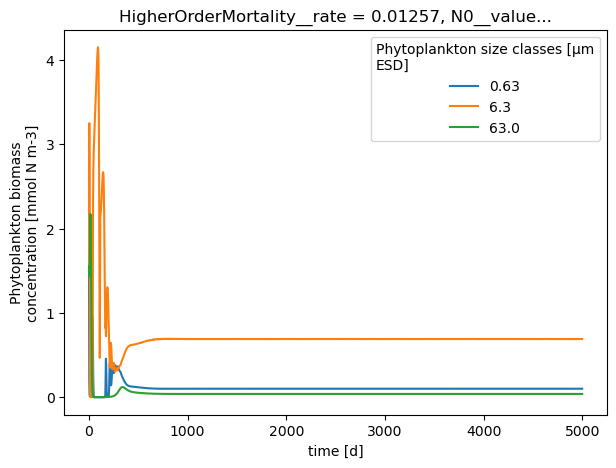

In [80]:
mort_n0_scan.isel(N0__value=1, HigherOrderMortality__rate=1).Phytoplankton__biomass.plot.line(x='time')

In [ ]:
mort_n0_scan.isel(N0__value=1, time=slice(365*9,365*10)).Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='HigherOrderMortality__rate')

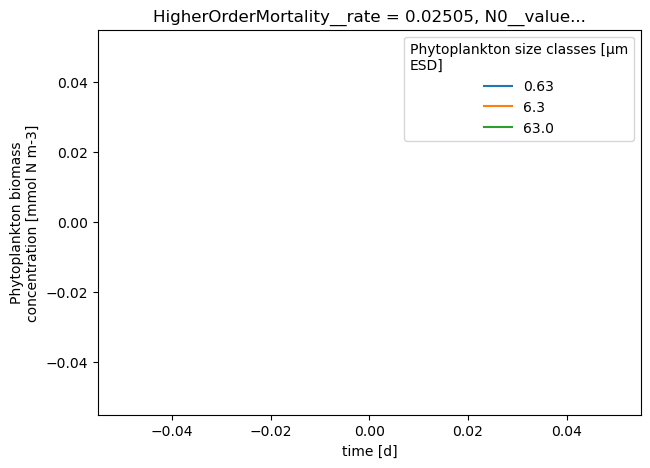

In [56]:
plt.rcParams['figure.figsize'] = [7, 5]
mort_n0_scan.isel(N0__value=5,HigherOrderMortality__rate=2, time=slice(365*9,365*10)).Phytoplankton__biomass.plot.line(x='time')

In [136]:
#mort_n0_scan.isel(time=slice(365*9,365*10), N0__value=4, HigherOrderMortality__rate=1).Phytoplankton__biomass.mean(dim="time")
mort_n0_scan.isel(time=slice(365*9,365*10), N0__value=4, HigherOrderMortality__rate=2).Phytoplankton__biomass.mean(dim="time")


<xarray.DataArray 'Phytoplankton__biomass' (phyto: 3)> Size: 24B
array([0.05563203, 0.35341649, 0.01015296])
Coordinates:
    HigherOrderMortality__rate  float64 8B 0.007229
    N0__value                   float64 8B 0.2
  * phyto                       (phyto) float64 24B 0.63 6.3 63.0

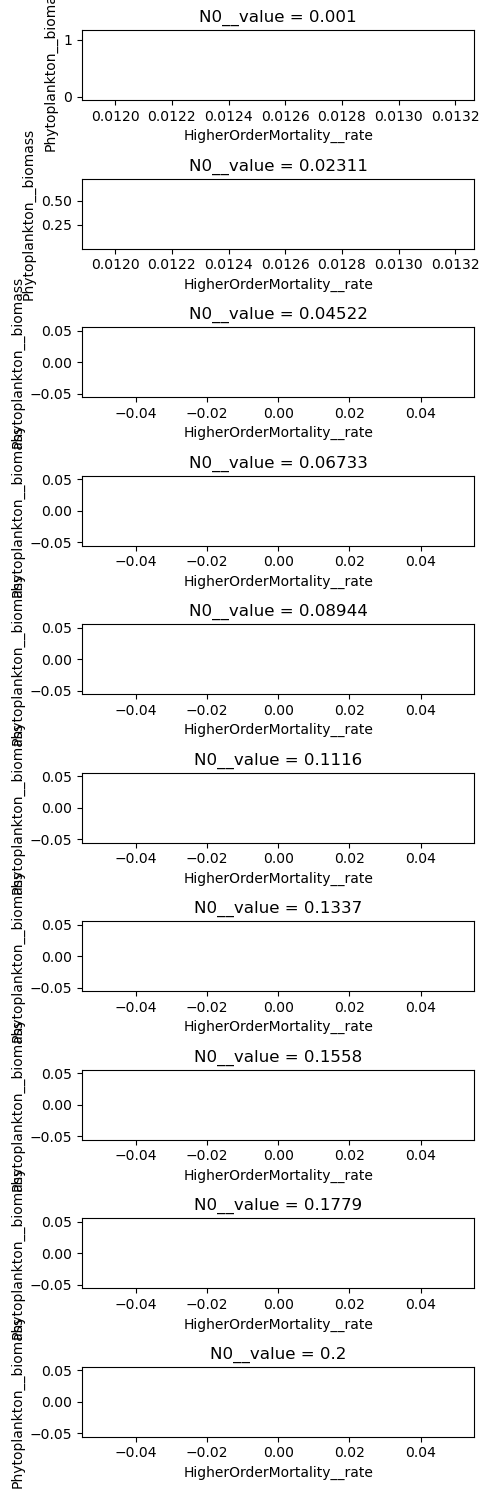

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 15]

parsetind_toplot = [0,1,2,3,4,5,6,7,8,9]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (mort_n0_scan
        .isel(time=slice(365*9,365*10), N0__value=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

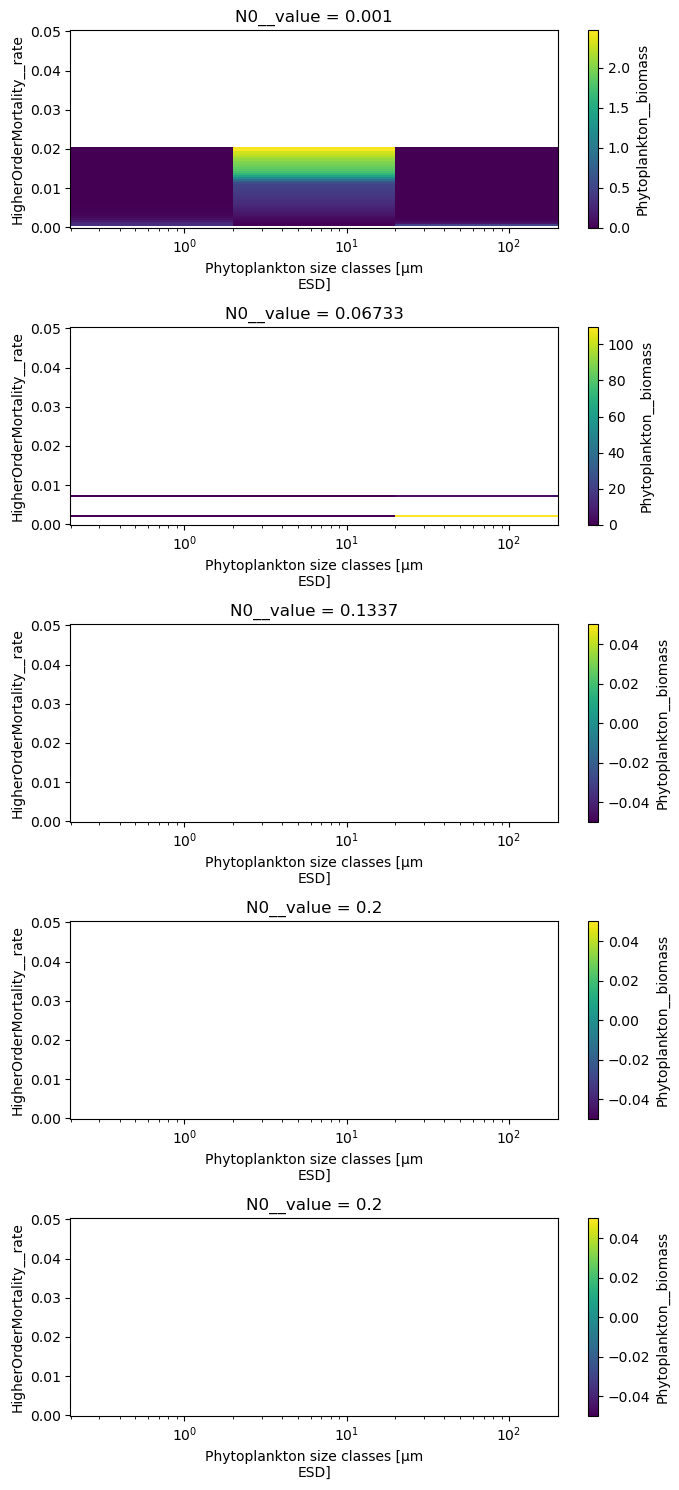

In [154]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [7, 15]

parsetind_toplot = [0,1,2,3,3]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (mort_n0_scan
        .isel(time=slice(365*9,365*10), N0__value=val)
        .Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='HigherOrderMortality__rate', ax=ax[ind]))#, ylim=(0,1)))


plt.tight_layout()

In [86]:
# Let's try varying another parameter (i.e. not N0__value)

In [88]:
gge_mort_scan_input = generate_iterable_2d_parscan('GGE__gge', np.linspace(0.1,0.6, 5),
                             'HigherOrderMortality__rate', np.linspace(0.0001,0.05, 10))

mort_gge_scan = run_model_get_output(gge_mort_scan_input)

pool started
running GGE__gge 0.1 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running GGE__gge 0.225 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running GGE__gge 0.35 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running GGE__gge 0.475 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running GGE__gge 0.6 HigherOrderMortality__rate
Full scan done in  41.62353 seconds
GGE__gge 0.1 HigherOrderMortality__rate
No event detected
Event triggered at t = [84.80780867]
No event detected
Event triggered at t = [86.35514692]
No event detected
Event triggered at t = [84.93918465]
No event detected
Event triggered at t = [103.75654101]
No event detected
Event triggered at t = [129.41717965]
No event detected
Event triggered at t = [112.8052208]
No event detected
No event detected
No event detected
Event triggered at t = [140.33065919]
No event detected
No event detected
No event detected
Event triggered at t = [250.83803981]
No event detected
Event triggered at t = [134.09206387]
Event triggered at t = [27.06638574]
No event detected
No event detected
Event triggered at t = [94.45905375]
No event detected
No event detected
Event triggered at t = [90.43976511]
No event detected
No event detected
Event triggered at t = [75.74326175]
No event detected
No event detected
Event trigge

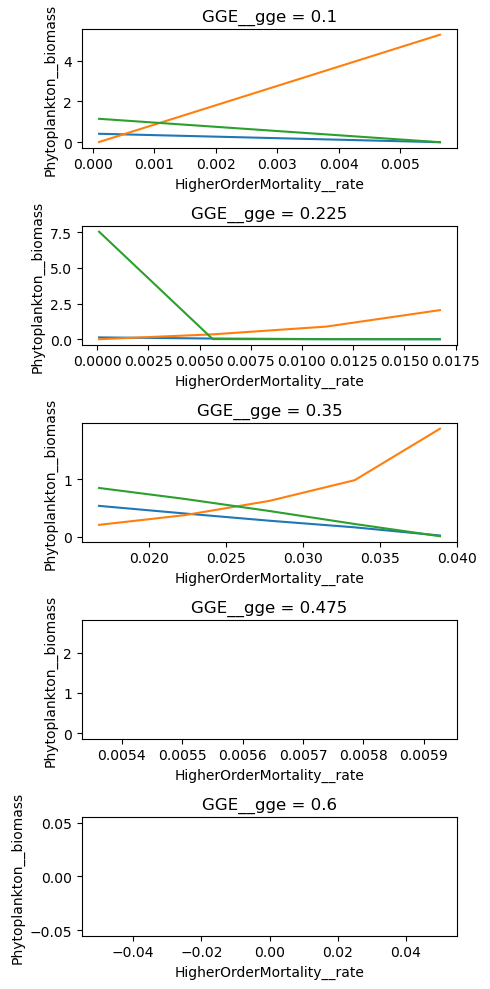

In [89]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (mort_gge_scan
        .isel(time=slice(365*9,365*10), GGE__gge=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

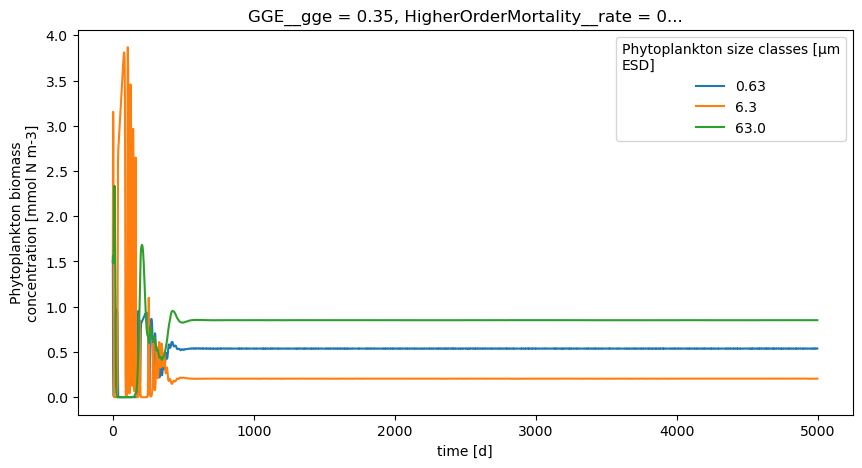

In [139]:
plt.rcParams['figure.figsize'] = [10, 5]
mort_gge_scan.Phytoplankton__biomass.isel(HigherOrderMortality__rate=3, GGE__gge=2).plot.line(x='time')

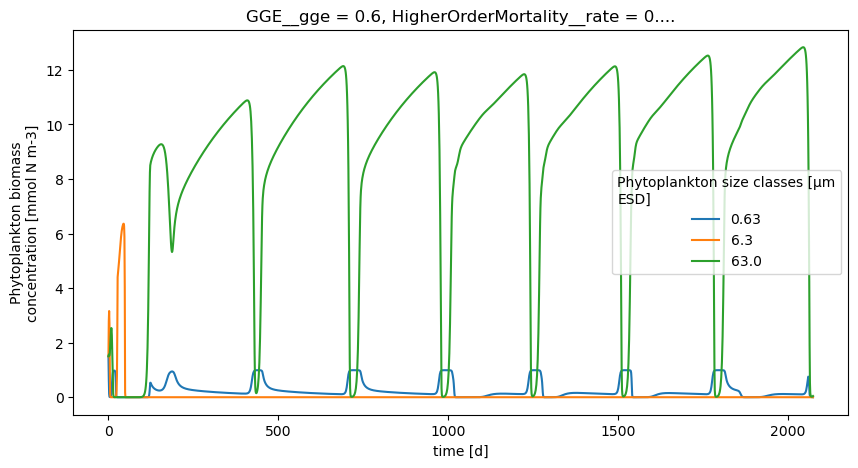

In [123]:

mort_gge_scan.Phytoplankton__biomass.isel(HigherOrderMortality__rate=1, GGE__gge=4).plot.line(x='time')

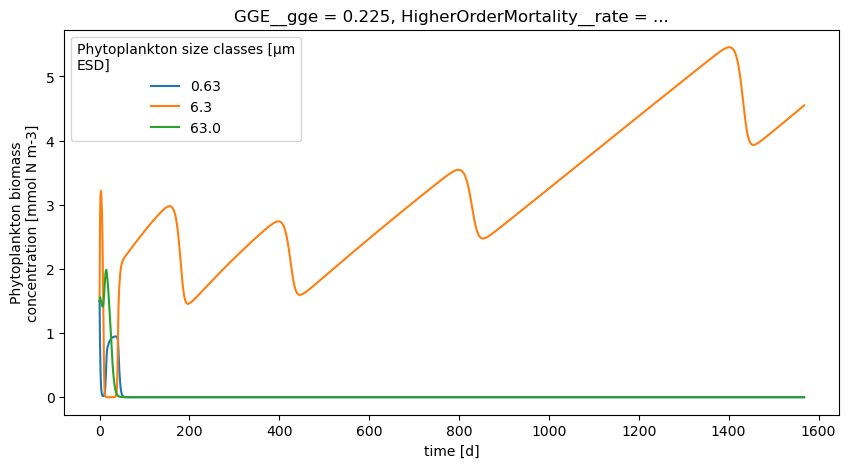

In [124]:
mort_gge_scan.Phytoplankton__biomass.isel(HigherOrderMortality__rate=4, GGE__gge=1).plot.line(x='time')

In [148]:
gge_mort_scan_input_2 = generate_iterable_2d_parscan('GGE__gge', np.linspace(0.3,0.4, 5),
                             'HigherOrderMortality__rate', np.linspace(0.001,0.05, 100))

mort_gge_scan_2 = run_model_get_output(gge_mort_scan_input_2)

pool started
running GGE__gge 0.3 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running GGE__gge 0.325 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running GGE__gge 0.35 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running GGE__gge 0.375 HigherOrderMortality__rate
running GGE__gge 0.4 HigherOrderMortality__rate


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


Full scan done in  163.77841 seconds
GGE__gge 0.3 HigherOrderMortality__rate
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [777.80204533]
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [173.16564337]
Event triggered at t = [79.75209696]
Event triggered at t = [211.61225608]
Event triggered at t = [106.54678979]
Event triggered at t = [122.0104374]
Event triggered at t = [196.83917558]
Event triggered at t = [651.09012528]
Event triggered at t = [643.00951524]
Event triggered at t = [132.00730914]
Event triggered at t = [103.01726465]
Event triggered at t = [140.51447814]
Event triggered at t = [105.53119599]
Event triggered at t = [123.29651087]
Event triggered at t = [212.4869973]
No event detected
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [457.53384198]
Event triggered at t = [3148.0

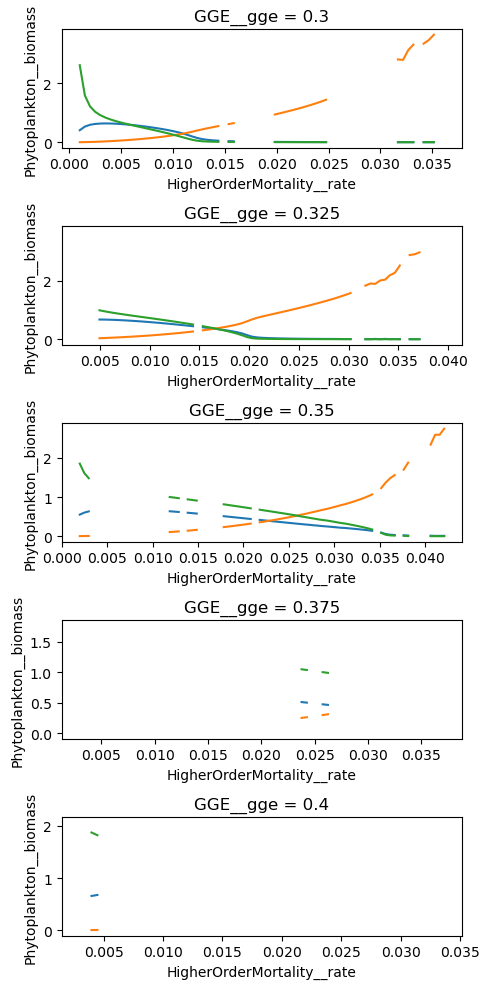

In [149]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (mort_gge_scan_2
        .isel(time=slice(365*9,365*10), GGE__gge=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()